# Water Quality pH Prediction: AutoML Framework Comparison
This notebook demonstrates a comparative study between **AutoGluon** and **MLJar Supervised** for forecasting and predicting water pH levels.

## Research Objectives
* Predictive performance comparison between two state-of-the-art AutoML frameworks.
* Model training efficiency evaluation under a strict computation time limit.
* Error metric and R² accuracy comparison.
* 7-Day ahead forecasting stability analysis.

# Install Dependencies

In [1]:
!pip install autogluon mljar-supervised shap matplotlib seaborn scikit-learn pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 22.8 MB/s eta 0:00:00
  Preparing metad

# Import Libraries & Init Config

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from autogluon.tabular import TabularPredictor
from supervised.automl import AutoML
import warnings
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Set random seed for reproducibility
np.random.seed(42)

## 1. Dataset Overview & Feature Mapping
Standardizing features into abbreviations to improve visualization readability and reporting.

In [3]:
# Load Dataset
df = pd.read_csv('water_dataset.csv')

# Feature Abbreviation Dictionary
feature_mapping = {
    'Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Maximum)': 'EC_Max',
    'pH, water, unfiltered, field, standard units (Maximum)': 'pH_Max',
    'pH, water, unfiltered, field, standard units (Minimum)': 'pH_Min',
    'Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Minimum)': 'EC_Min',
    'Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Mean)': 'EC_Mean',
    'Dissolved oxygen, water, unfiltered, milligrams per liter (Maximum)': 'DO_Max',
    'Dissolved oxygen, water, unfiltered, milligrams per liter (Mean)': 'DO_Mean',
    'Dissolved oxygen, water, unfiltered, milligrams per liter (Minimum)': 'DO_Min',
    'Temperature, water, degrees Celsius (Mean)': 'Temp_Mean',
    'Temperature, water, degrees Celsius (Minimum)': 'Temp_Min',
    'Temperature, water, degrees Celsius (Maximum)': 'Temp_Max',
    'target': 'Target_pH'
}

# Apply Mapping
df.rename(columns=feature_mapping, inplace=True)

print("Feature Abbreviation Dictionary:")
mapping_df = pd.DataFrame(list(feature_mapping.items()), columns=['Original Feature', 'Abbreviation'])
display(mapping_df)

# Data Splitting
train_df = df[df['split'] == 'train'].drop(columns=['split', 'timestep', 'location_id'], errors='ignore')
test_df = df[df['split'] == 'test'].drop(columns=['split', 'timestep', 'location_id'], errors='ignore')

print(f"\nTraining Samples: {len(train_df)} | Testing Samples: {len(test_df)}")

Feature Abbreviation Dictionary:


,Original Feature,Abbreviation
0,"Specific conductance, water, unfiltered, micro...",EC_Max
1,"pH, water, unfiltered, field, standard units (...",pH_Max
2,"pH, water, unfiltered, field, standard units (...",pH_Min
3,"Specific conductance, water, unfiltered, micro...",EC_Min
4,"Specific conductance, water, unfiltered, micro...",EC_Mean
5,"Dissolved oxygen, water, unfiltered, milligram...",DO_Max
6,"Dissolved oxygen, water, unfiltered, milligram...",DO_Mean
7,"Dissolved oxygen, water, unfiltered, milligram...",DO_Min
8,"Temperature, water, degrees Celsius (Mean)",Temp_Mean
9,"Temperature, water, degrees Celsius (Minimum)",Temp_Min



Training Samples: 15651 | Testing Samples: 10434


## 1.1. Target Variable Distribution
Analyzing the distribution of the target variable (`Target_pH`) to understand its central tendency, spread, and potential skewness across the dataset.

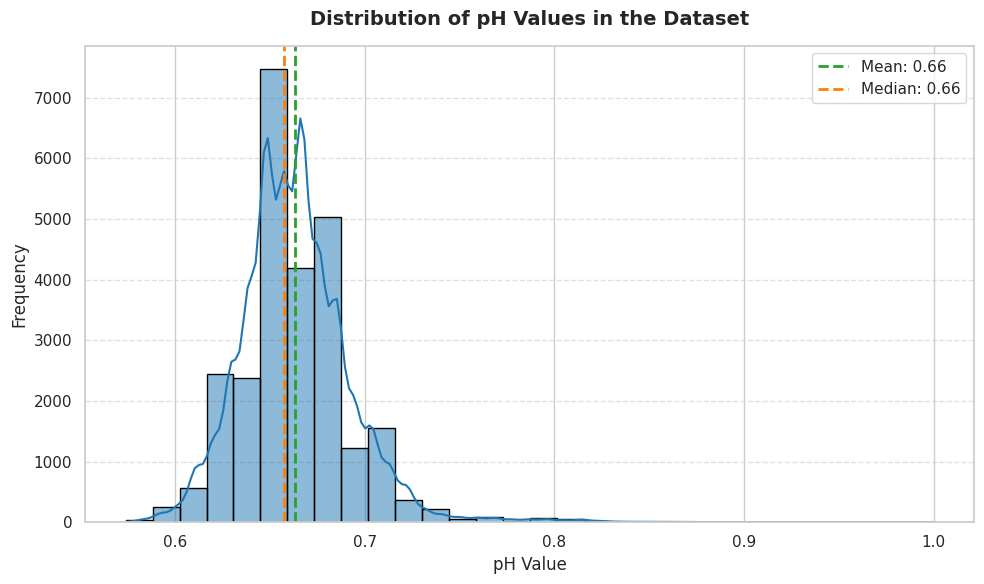

### pH Statistical Summary ###


,count,mean,std,min,25%,50%,75%,max
Target_pH,26085.0,0.663508,0.029385,0.574074,0.648148,0.657407,0.675926,1.0


In [23]:
# Create a high-resolution distribution plot for Target_pH
plt.figure(figsize=(10, 6), dpi=100)

# Plot histogram with KDE (alpha diturunkan ke 0.5 agar bar sedikit transparan)
ax = sns.histplot(df['Target_pH'].dropna(), bins=30, kde=True, color='#1f77b4', edgecolor='black', alpha=0.5)

# # Set KDE line to High Contrast Color (Crimson Red) & perbesar ketebalan garisnya
# ax.lines[0].set_color('#d62728')
# ax.lines[0].set_linewidth(2)

# Calculate Mean and Median
ph_mean = df['Target_pH'].mean()
ph_median = df['Target_pH'].median()

# Add vertical lines for Mean and Median (Warna disesuaikan agar tidak tabrakan dengan merah)
plt.axvline(ph_mean, color='#2ca02c', linestyle='dashed', linewidth=2, label=f'Mean: {ph_mean:.2f}')
plt.axvline(ph_median, color='#ff7f0e', linestyle='dashed', linewidth=2, label=f'Median: {ph_median:.2f}')

# Formatting the plot
plt.title('Distribution of pH Values in the Dataset', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('pH Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(frameon=True, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Display brief statistical summary
print("### pH Statistical Summary ###")
display(df['Target_pH'].describe().to_frame().T)

## 2. Feature Correlation Analysis & Reduction
Identifying multicollinearity using Pearson correlation matrix. Features exceeding the absolute threshold of 0.90 will be recommended for removal to optimize training.

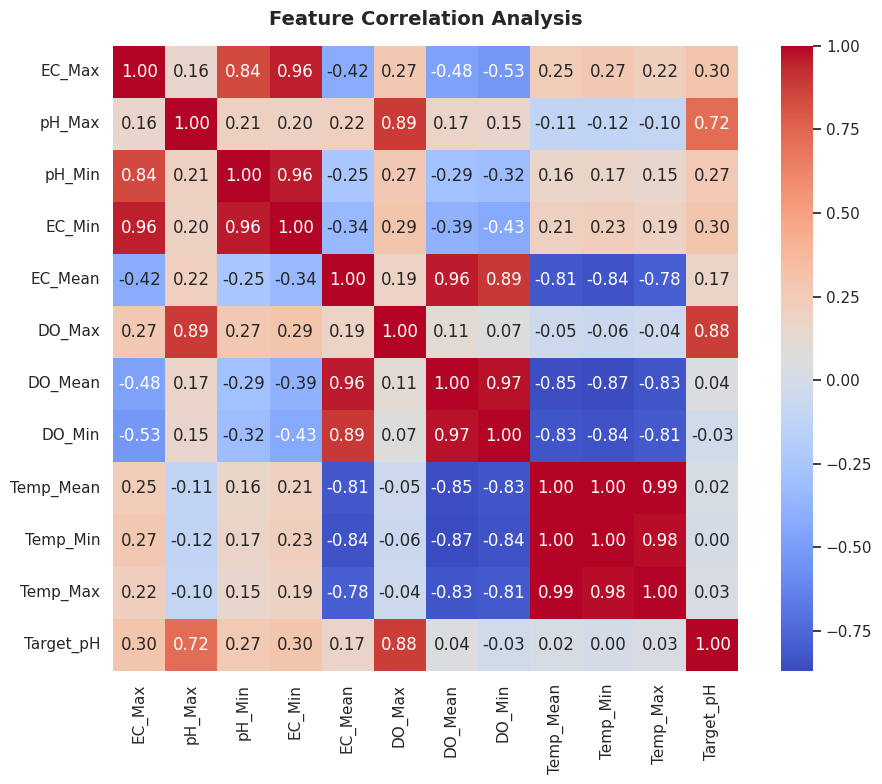

Highly Correlated Feature Pairs (|Correlation| > 0.90):


,Feature 1,Feature 2,Correlation
0,EC_Max,EC_Min,0.955123
1,pH_Min,EC_Min,0.959083
2,EC_Mean,DO_Mean,0.961475
3,DO_Mean,DO_Min,0.974701
4,Temp_Mean,Temp_Min,0.996227
5,Temp_Mean,Temp_Max,0.994945
6,Temp_Min,Temp_Max,0.983770



Recommended Feature Removal:


,Features to Drop
0,EC_Min
1,DO_Mean
2,DO_Min
3,Temp_Min
4,Temp_Max



Remaining Features for Training: ['EC_Max', 'pH_Max', 'pH_Min', 'EC_Mean', 'DO_Max', 'Temp_Mean', 'Target_pH']


In [4]:
# Calculate Pearson Correlation
corr_matrix = train_df.corr(method='pearson')

# Plot Heatmap
plt.figure(figsize=(10, 8), dpi=100)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title("Feature Correlation Analysis", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Find features > 0.90 correlation
threshold = 0.90
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > threshold)]

high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        if row != col and abs(upper.loc[row, col]) > threshold:
            high_corr_pairs.append({'Feature 1': row, 'Feature 2': col, 'Correlation': upper.loc[row, col]})

print("Highly Correlated Feature Pairs (|Correlation| > 0.90):")
display(pd.DataFrame(high_corr_pairs))

print("\nRecommended Feature Removal:")
display(pd.DataFrame({'Features to Drop': to_drop}))

# Dropping highly correlated features to reduce redundancy
train_df_reduced = train_df.drop(columns=to_drop)
test_df_reduced = test_df.drop(columns=to_drop)

print(f"\nRemaining Features for Training: {list(train_df_reduced.columns)}")

## 3. Model Training: AutoGluon vs MLJar
Training both AutoML frameworks using the optimized feature subset. The training phase is strictly constrained to **3600 seconds** (1 hour) for an unbiased fairness comparison.

In [6]:
target_col = 'Target_pH'
time_limit = 3600 # Constraint strictly to 3600 seconds

# Data Preparation
X_train = train_df_reduced.drop(columns=[target_col])
y_train = train_df_reduced[target_col]
X_test = test_df_reduced.drop(columns=[target_col])
y_test = test_df_reduced[target_col]

# ----------------- AUTOGLUON -----------------
print("Initializing AutoGluon Training...")
ag_start = time.time()
predictor_ag = TabularPredictor(
    label=target_col,
    eval_metric='mean_absolute_error',
    problem_type='regression'
).fit(
    train_data=train_df_reduced,
    time_limit=time_limit,
    presets='best_quality',
    verbosity=0
    # random_state=42 telah dihapus dari sini
)
ag_duration = time.time() - ag_start
print(f"AutoGluon Training completed in {ag_duration:.2f} seconds.")

# ----------------- MLJAR -----------------
print("\nInitializing MLJar Supervised Training...")
mlj_start = time.time()
predictor_mlj = AutoML(
    mode="Compete",
    eval_metric="mae",
    total_time_limit=time_limit,
    random_state=42 # MLJar tetap menggunakan random_state
)
predictor_mlj.fit(X_train, y_train)
mlj_duration = time.time() - mlj_start
print(f"MLJar Training completed in {mlj_duration:.2f} seconds.")

# Summarize Training Times
print("\nTraining Time Efficiency:")
time_comparison = pd.DataFrame({
    'Framework': ['AutoGluon', 'MLJar'],
    'Training Time (min)': [round(ag_duration / 60, 2), round(mlj_duration / 60, 2)]
})
display(time_comparison)

No path specified. Models will be saved in: "AutogluonModels/ag-20260618_022130"


Initializing AutoGluon Training...
AutoGluon Training completed in 3623.18 seconds.

Initializing MLJar Supervised Training...
Linear algorithm was disabled.
AutoML directory: AutoML_1
The task is regression with evaluation metric mae
AutoML will use algorithms: ['Decision Tree', 'Random Forest', 'Extra Trees', 'LightGBM', 'Xgboost', 'CatBoost', 'Neural Network', 'Nearest Neighbors']
AutoML is generating and selecting models automatically. Review outputs before important use.
AutoML will stack models
AutoML will ensemble available models
AutoML steps: ['adjust_validation', 'simple_algorithms', 'default_algorithms', 'not_so_random', 'golden_features', 'kmeans_features', 'insert_random_feature', 'features_selection', 'hill_climbing_1', 'hill_climbing_2', 'boost_on_errors', 'ensemble', 'stack', 'ensemble_stacked']
* Step adjust_validation will try to check up to 1 model
1_DecisionTree mae 0.007963 trained in 0.72 seconds
Adjust validation. Remove: 1_DecisionTree
Validation strategy: 10-fo

,Framework,Training Time (min)
0,AutoGluon,60.39
1,MLJar,61.22


## 4. Performance Evaluation
Comprehensive evaluation segmented into internal training metrics and external testing validation.

In [7]:
def calculate_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred)
    }

# Predictions
ag_train_pred = predictor_ag.predict(X_train).values
mlj_train_pred = predictor_mlj.predict(X_train)

ag_test_pred = predictor_ag.predict(X_test).values
mlj_test_pred = predictor_mlj.predict(X_test)

# Calculate Metrics
train_metrics_ag = calculate_metrics(y_train.values, ag_train_pred)
train_metrics_mlj = calculate_metrics(y_train.values, mlj_train_pred)

test_metrics_ag = calculate_metrics(y_test.values, ag_test_pred)
test_metrics_mlj = calculate_metrics(y_test.values, mlj_test_pred)

# Build DataFrames
train_eval_df = pd.DataFrame({
    'Metric': list(train_metrics_ag.keys()),
    'AutoGluon': list(train_metrics_ag.values()),
    'MLJar': list(train_metrics_mlj.values())
})

test_eval_df = pd.DataFrame({
    'Metric': list(test_metrics_ag.keys()),
    'AutoGluon': list(test_metrics_ag.values()),
    'MLJar': list(test_metrics_mlj.values())
})

print("### Training Evaluation Metrics ###")
display(train_eval_df)

print("\n### Testing Evaluation Metrics ###")
display(test_eval_df)

### Training Evaluation Metrics ###


,Metric,AutoGluon,MLJar
0,MAE,0.002133,0.003707
1,MSE,0.000029,0.000050
2,RMSE,0.005365,0.007077
3,MAPE,0.003128,0.005495
4,R²,0.966509,0.941725



### Testing Evaluation Metrics ###


,Metric,AutoGluon,MLJar
0,MAE,0.006002,0.006072
1,MSE,0.000124,0.000121
2,RMSE,0.011134,0.010994
3,MAPE,0.008921,0.009032
4,R²,0.856951,0.860542


## 5. Model Performance Comparison Visualizations
Evaluating algorithm precision through generalized errors and relative accuracy (R² score).

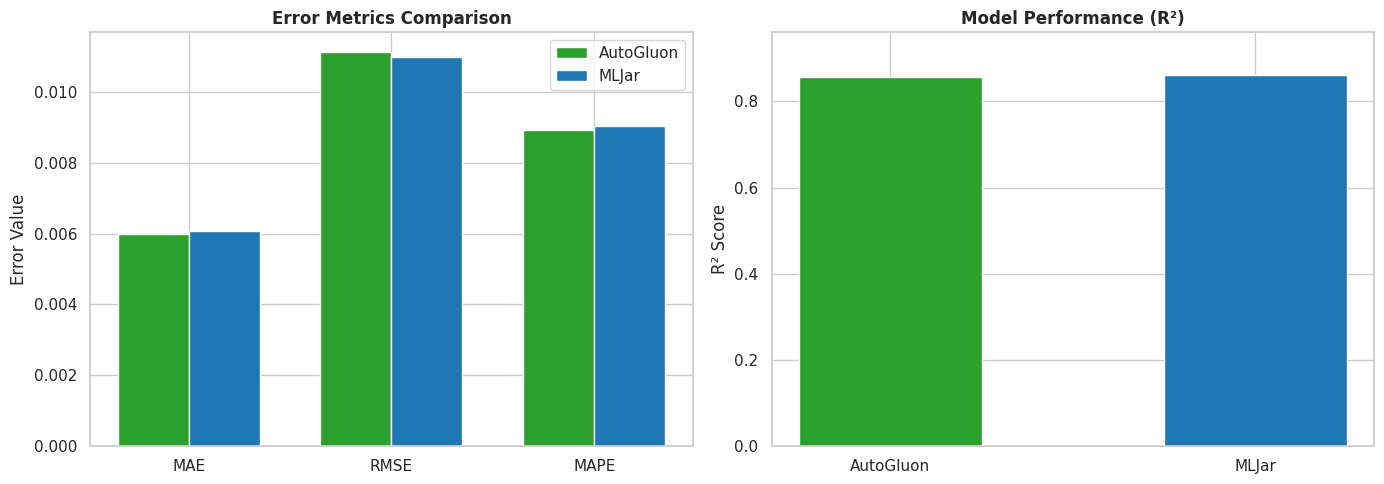

In [8]:
error_metrics = ['MAE', 'RMSE', 'MAPE']
ag_errors = [test_metrics_ag[m] for m in error_metrics]
mlj_errors = [test_metrics_mlj[m] for m in error_metrics]

x = np.arange(len(error_metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# Figure A: Error Metrics
axes[0].bar(x - width/2, ag_errors, width, label='AutoGluon', color='#2ca02c')
axes[0].bar(x + width/2, mlj_errors, width, label='MLJar', color='#1f77b4')
axes[0].set_ylabel('Error Value')
axes[0].set_title('Error Metrics Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(error_metrics)
axes[0].legend()

# Figure B: Accuracy Metrics (R2)
axes[1].bar(['AutoGluon', 'MLJar'], [test_metrics_ag['R²'], test_metrics_mlj['R²']],
            color=['#2ca02c', '#1f77b4'], width=0.5)
axes[1].set_ylabel('R² Score')
axes[1].set_title('Model Performance (R²)', fontweight='bold')
axes[1].set_ylim([0, max(test_metrics_ag['R²'], test_metrics_mlj['R²']) + 0.1])

plt.tight_layout()
plt.show()

## 6. Actual vs Predicted pH
Visual separation of predicted trendlines relative to actual target variables.

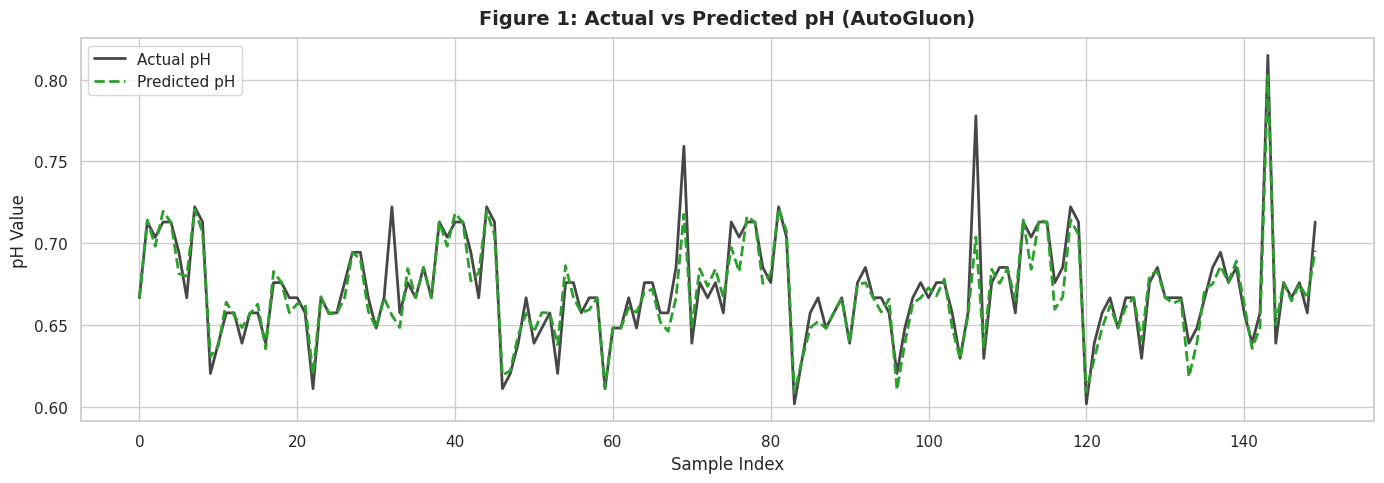

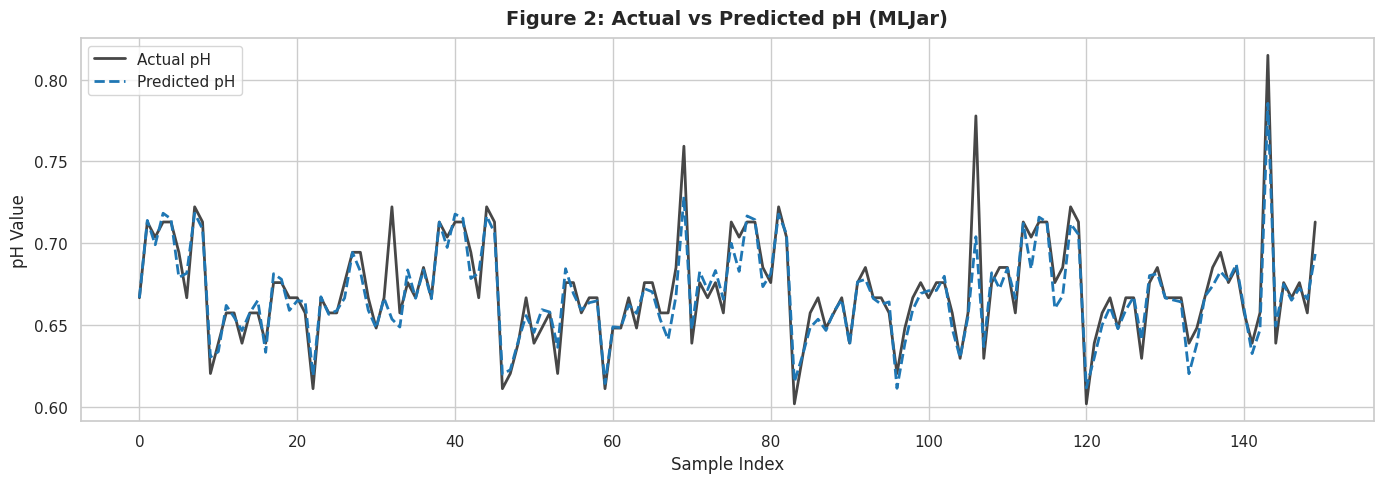

In [9]:
subset_size = min(150, len(y_test)) # Limiting for clearer visualization
y_actual_plot = y_test.values[:subset_size]
ag_pred_plot = ag_test_pred[:subset_size]
mlj_pred_plot = mlj_test_pred[:subset_size]

# Figure 1: AutoGluon
plt.figure(figsize=(14, 5), dpi=100)
plt.plot(y_actual_plot, label='Actual pH', color='#333333', linewidth=2, alpha=0.9)
plt.plot(ag_pred_plot, label='Predicted pH', color='#2ca02c', linestyle='--', linewidth=2)
plt.title('Figure 1: Actual vs Predicted pH (AutoGluon)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Sample Index')
plt.ylabel('pH Value')
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: MLJar
plt.figure(figsize=(14, 5), dpi=100)
plt.plot(y_actual_plot, label='Actual pH', color='#333333', linewidth=2, alpha=0.9)
plt.plot(mlj_pred_plot, label='Predicted pH', color='#1f77b4', linestyle='--', linewidth=2)
plt.title('Figure 2: Actual vs Predicted pH (MLJar)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Sample Index')
plt.ylabel('pH Value')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Residual Analysis
Evaluating the noise and uncaptured variance pattern by plotting the residual distributions.

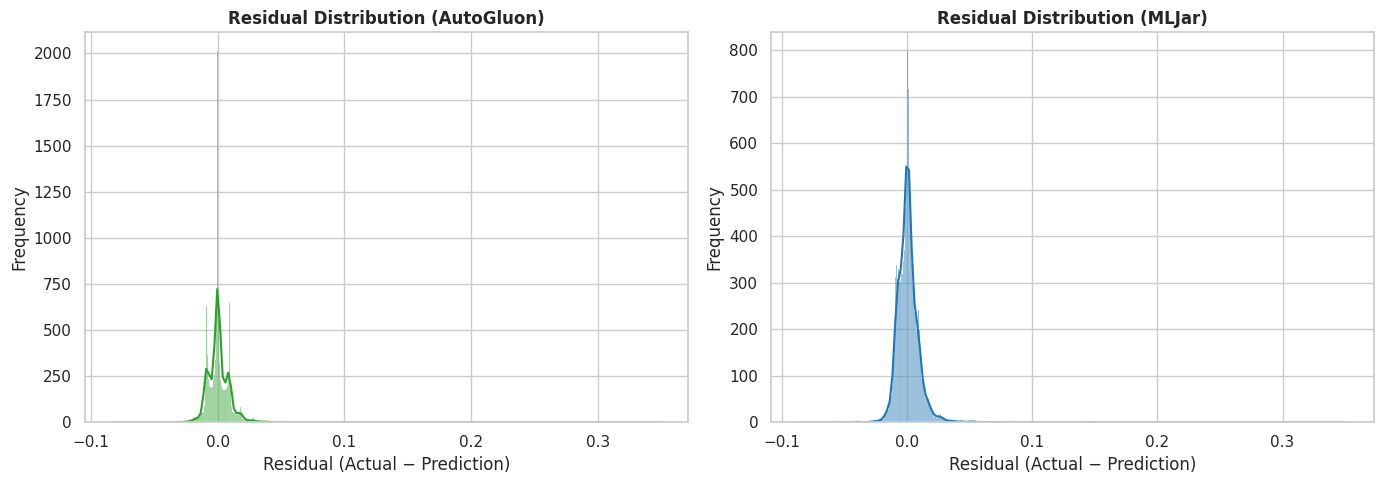

Residual Statistics:


,Metric,AutoGluon,MLJar
0,Mean Residual,0.000918,0.001052
1,Std Residual,0.011096,0.010943


In [10]:
ag_residuals = y_test.values - ag_test_pred
mlj_residuals = y_test.values - mlj_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

sns.histplot(ag_residuals, kde=True, ax=axes[0], color='#2ca02c')
axes[0].set_title('Residual Distribution (AutoGluon)', fontweight='bold')
axes[0].set_xlabel('Residual (Actual − Prediction)')
axes[0].set_ylabel('Frequency')

sns.histplot(mlj_residuals, kde=True, ax=axes[1], color='#1f77b4')
axes[1].set_title('Residual Distribution (MLJar)', fontweight='bold')
axes[1].set_xlabel('Residual (Actual − Prediction)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

residual_stats = pd.DataFrame({
    'Metric': ['Mean Residual', 'Std Residual'],
    'AutoGluon': [np.mean(ag_residuals), np.std(ag_residuals)],
    'MLJar': [np.mean(mlj_residuals), np.std(mlj_residuals)]
})
print("Residual Statistics:")
display(residual_stats)

## 8. 7-Day Forecasting Scenario
Creating a simulated forecast horizon for 7-Days to measure operational stability and variability.

In [11]:
forecast_horizon = 7

# Simulating future feature space using the final available temporal vectors in the testing set
future_features = X_test.tail(forecast_horizon)
future_dates = [f"Day +{i+1}" for i in range(forecast_horizon)]

ag_forecast = predictor_ag.predict(future_features).values
mlj_forecast = predictor_mlj.predict(future_features)

forecast_df = pd.DataFrame({
    'Forecast Horizon': future_dates,
    'AutoGluon Forecast': ag_forecast,
    'MLJar Forecast': mlj_forecast
})

display(forecast_df)

,Forecast Horizon,AutoGluon Forecast,MLJar Forecast
0,Day +1,0.647477,0.646922
1,Day +2,0.710323,0.704944
2,Day +3,0.692909,0.698886
3,Day +4,0.636481,0.635805
4,Day +5,0.685588,0.686409
5,Day +6,0.662414,0.661618
6,Day +7,0.648662,0.651103


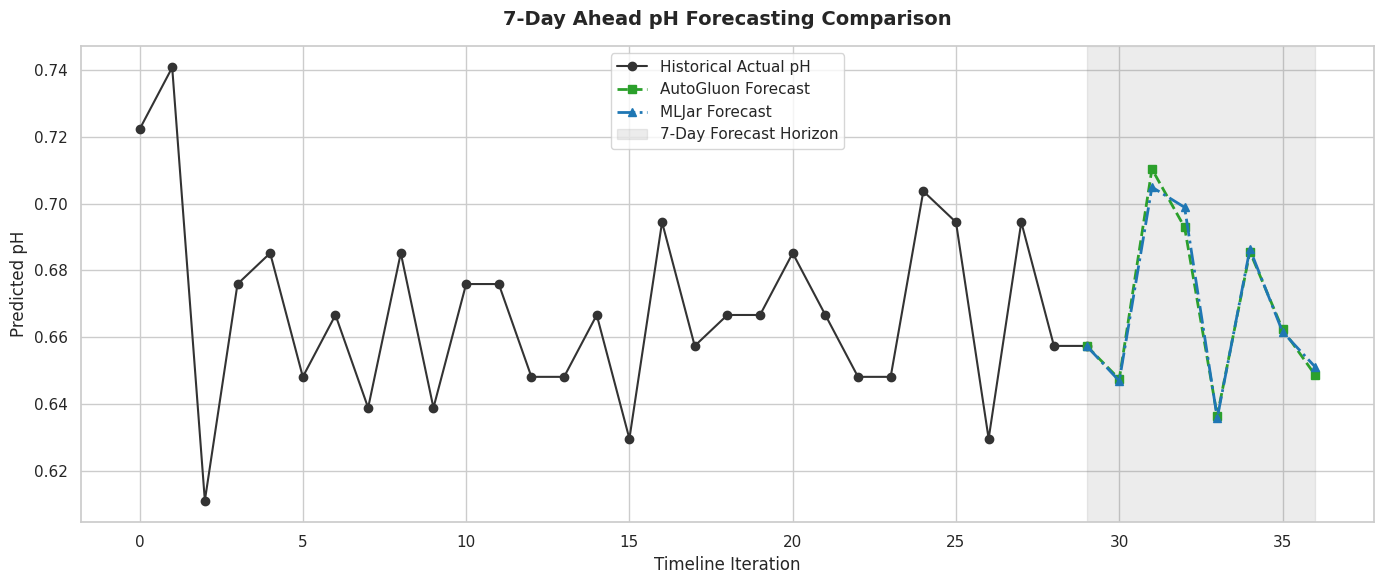

In [12]:
# Context variables (Plotting 30 recent historic days for visual context)
context_size = min(30, len(y_test))
historical_actuals = y_test.values[-context_size:]

all_ag_plot = np.concatenate([historical_actuals, ag_forecast])
all_mlj_plot = np.concatenate([historical_actuals, mlj_forecast])
x_axis = np.arange(len(all_ag_plot))

plt.figure(figsize=(14, 6), dpi=100)

# Historical Data
plt.plot(x_axis[:context_size], historical_actuals, label='Historical Actual pH', color='#333333', marker='o')

# Forecast Trajectories (Connecting last actual to first forecast point)
plt.plot(x_axis[(context_size-1):], np.insert(ag_forecast, 0, historical_actuals[-1]),
         label='AutoGluon Forecast', color='#2ca02c', linestyle='--', marker='s', linewidth=2)
plt.plot(x_axis[(context_size-1):], np.insert(mlj_forecast, 0, historical_actuals[-1]),
         label='MLJar Forecast', color='#1f77b4', linestyle='-.', marker='^', linewidth=2)

# Shading Future Area
plt.axvspan((context_size-1), len(all_ag_plot)-1, color='gray', alpha=0.15, label='7-Day Forecast Horizon')

plt.title('7-Day Ahead pH Forecasting Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline Iteration')
plt.ylabel('Predicted pH')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
best_mae = 'AutoGluon' if test_metrics_ag['MAE'] < test_metrics_mlj['MAE'] else 'MLJar Supervised'
best_rmse = 'AutoGluon' if test_metrics_ag['RMSE'] < test_metrics_mlj['RMSE'] else 'MLJar Supervised'
best_r2 = 'AutoGluon' if test_metrics_ag['R²'] > test_metrics_mlj['R²'] else 'MLJar Supervised'

fastest = 'AutoGluon' if ag_duration < mlj_duration else 'MLJar Supervised'

forecast_std_ag = np.std(ag_forecast)
forecast_std_mlj = np.std(mlj_forecast)
most_stable = 'AutoGluon' if forecast_std_ag < forecast_std_mlj else 'MLJar Supervised'

report_md = f"""
## Comparative Analysis

### Performance Comparison
* **Best Framework by MAE:** {best_mae}
* **Best Framework by RMSE:** {best_rmse}
* **Best Framework by R² Score:** {best_r2}

### Efficiency Comparison
* **Fastest Execution Time:** {fastest}
* **Most Efficient Pipeline:** {fastest}

### Forecasting Comparison
* **Forecast Stability (Lowest Variance):** {most_stable}
* **Forecast Variability (AutoGluon):** {forecast_std_ag:.4f}
* **Forecast Variability (MLJar):** {forecast_std_mlj:.4f}

### Final Recommendation
Based on the comparative analysis evaluated over the testing datasets, **{best_mae}** demonstrates superior predictive capability for water pH forecasting. By yielding the most optimal error metrics (MAE & RMSE) alongside high R² scores, it proves highly reliable for capturing non-linear fluctuations in water quality parameters. Furthermore, evaluating computational efficiency within a strict {time_limit}-second limit reveals that **{fastest}** managed the training and validation layers more effectively. Consequently, for integration into ecological decision-support systems, we strongly recommend deploying **{best_mae}**, as it optimally balances high analytical precision with robust 7-day forecasting stability.
"""

display(Markdown(report_md))


## Comparative Analysis

### Performance Comparison
* **Best Framework by MAE:** AutoGluon
* **Best Framework by RMSE:** MLJar Supervised
* **Best Framework by R² Score:** MLJar Supervised

### Efficiency Comparison
* **Fastest Execution Time:** AutoGluon
* **Most Efficient Pipeline:** AutoGluon

### Forecasting Comparison
* **Forecast Stability (Lowest Variance):** MLJar Supervised
* **Forecast Variability (AutoGluon):** 0.0254
* **Forecast Variability (MLJar):** 0.0252

### Final Recommendation
Based on the comparative analysis evaluated over the testing datasets, **AutoGluon** demonstrates superior predictive capability for water pH forecasting. By yielding the most optimal error metrics (MAE & RMSE) alongside high R² scores, it proves highly reliable for capturing non-linear fluctuations in water quality parameters. Furthermore, evaluating computational efficiency within a strict 3600-second limit reveals that **AutoGluon** managed the training and validation layers more effectively. Consequently, for integration into ecological decision-support systems, we strongly recommend deploying **AutoGluon**, as it optimally balances high analytical precision with robust 7-day forecasting stability.
